# Multi-cell analysis: LiFi 1.0 (LED) vs LiFi 2.0 (VCSEL)

This notebook extends the single-cell analysis to a multi-cell scenario: several access points (APs) are placed on the ceiling, each one creating its own cell, and the cells now interfere with each other.

Comparing the two technologies at some arbitrary equal setting would not have too much sense here because their transmit powers differ by orders of magnitude that are not related to communications concepts, since the LED's watts pay for room lighting while the VCSEL is capped by eye safety. So instead of fixing a power, this analysis fixes a **service level** (a coverage or rate target) and asks what deployment each technology needs to reach it in order to compare both technologies and analyze their best use cases. 

Every paper cited in this notebook is stored in the [`sources/`](sources/) folder.

**Table of contents**

- [1. Introduction](#1.-Introduction)
- [2. System model](#2.-System-model)
    - [2.1 Scenario and transmission models](#2.1-Scenario-and-transmission-models)
    - [2.2 The eye-safety budget: why 5 mW](#2.2-The-eye-safety-budget:-why-5-mW)
    - [2.3 Channel, association, SINR and capacity](#2.3-Channel,-association,-SINR-and-capacity)
    - [2.4 Implementation](#2.4-Implementation)
    - [2.5 Directivity: the two transmitters side by side](#2.5-Directivity:-the-two-transmitters-side-by-side)
    - [2.6 Metrics](#2.6-Metrics)
    - [2.7 Traceability of every decision](#2.7-Traceability-of-every-decision)
- [3. Case 1 - equal coverage target](#3.-Case-1---equal-coverage-target)
- [4. Case 2 - equal infrastructure](#4.-Case-2---equal-infrastructure)
- [5. Case 3 - cross-equivalence](#5.-Case-3---cross-equivalence)
- [6. Case 4 - scalability and densification](#6.-Case-4---scalability-and-densification)
- [7. Cooperative networks](#7.-Cooperative-networks)
- [8. Results and discussion](#8.-Results-and-discussion)
- [9. Conclusions](#9.-Conclusions)
- [10. Limitations](#10.-Limitations)
- [11. References](#11.-References)

## 1. Introduction

| | **LiFi 1.0 (LED)** | **LiFi 2.0 (VCSEL)** |
|---|---|---|
| Bandwidth | 20 MHz: rate is capped no matter the power (`[RIS-VLC]` Table III) | 2 GHz (`[VCSEL-Precoding]` Table I); 18 GHz devices already exist (`[VCSEL-70Gbps]`) |
| Directivity | very low: a wide Lambertian lobe, good for lighting, but it gives energy into neighbouring cells | very high: a narrow Gaussian beam that does not reach the next cell |
| Power limit | fixed by the illumination requirement, a room-level constraint | fixed by eye safety, a per-source constraint in the milliwatt range |
| Architecture | one emitter per AP, the luminaire itself | dense arrays of emitters (`[VCSEL-Precoding]`: 4x4-8x8 at 10 um pitch) |

The single-cell notebook already showed that neither technology works alone: one LED covers only its FoV disk (35% of the room), and one VCSEL covers essentially nothing. That leaves a network question rather than a single-link one: how many APs, how much power, and how much interference.

---

## 2. System model

### 2.1 Scenario and transmission models

The room is 5 x 5 x 3 m. 

APs sit on the ceiling (height 3 m) in an N x N lattice spanning the room, evaluated for N = 2, 3 and 4(generalizing the 2x2 benchmark of `[RIS-VLC]` into the natural design space for densification, since each extra row/column of APs is what a denser deployment physically means). 

Users are modelled as a uniform grid of receivers on the desk plane (height 1 m, so $\Delta z$ = 2 m below the ceiling), evaluated over a 200 x 200 grid, each one pointing straight up with no blockage. The receiver itself is identical for both technologies ($A_{PD}$ = 1 cm^2, FoV $\Psi_c$ = 40 deg, concentrator $n$ = 1.5), the same unification used in the single-cell notebook, since the FoV is considered as a property of the photodiode rather than of the source.

**LiFi 1.0: LED AP.** Each AP is a single Lambertian emitter ($m$ = 0.40). Its power is set so the deployment meets the lighting standard: average illuminance at least 500 lux, peak at most 800 lux, uniformity at least 0.5 (`[RIS-VLC]` eqs. (24)-(26), constraints C5-C8). As a consequence, the total optical power is fixed by the room itself, hence adding more APs just splits the same lighting budget rather than adding more power.

**LiFi 2.0: VCSEL AP.** Each AP is an array of $M = m \times m$ emitters whose beams tile the AP's cell, with beam selection: the AP activates only the emitter aimed closest to the user. Full precoding optimization requires channel state information and multi-user scheduling; since this work focuses on comparing transmitter architectures rather than optimizing algorithms, beam selection is adopted as a simplified representation of directional steering capabilities. It captures the essential capability of putting energy where the user actually is, and it is conservative relative to `[VCSEL-Precoding]`'s own precoding, since real precoding has more degrees of freedom to exploit.

### 2.2 The eye-safety budget: why 5 mW

The single-cell notebook used a 225 mW eye-safety ceiling, but that value wont be used here:

- It came from running the `[Eye-Safety]` algorithm with $w_0 = 0.45\ \mu m$ (`[VCSEL-Precoding]` Table I), a beam waist smaller than the wavelength itself, which violates the paraxial regime the Gaussian-beam model assumes and produces an unphysically divergent beam. A more divergent beam spreads its power out, so the eye-safe ceiling the algorithm returns comes out inflated.
- This notebook instead uses $w_0 = 5\ \mu m$, the realistic value `[Eye-Safety]` itself uses in its own worked examples (Figs. 7, 9, 13, 16-18). The power anchor has to stay consistent with the beam that produces it, so the 225 mW figure is dropped.
- With $w_0 = 5\ \mu m$, `[Eye-Safety]` Fig. 18(b) gives a maximum eye-safe power of a few milliwatts at 950 nm. Independently, `[VCSEL-70Gbps]` operates its 940 nm VCSEL at about 5 mW (Fig. 1). Two independent sources agreeing on the same order of magnitude is what sets the **5 mW per active emitter** used throughout this notebook.

`[Eye-Safety]` (Sec. III-C) classifies sources by their angular subtense ($\alpha_{min}$ = 1.5 mrad, $\alpha_{max}$ = 100 mrad, with the MPE relaxed for extended sources via $C_6$). 

Applied here: APs sit metres apart, so each gets an independent eye-safety budget; emitters inside one AP sit only 10 um apart, so they share a single budget. Since beam selection only ever turns on one emitter at a time, that one emitter gets the full 5 mW.

> The array buys the ability to aim, not more power.

### 2.3 Channel, association, SINR and capacity

The channel models are the same ones validated in the single-cell notebook: the LED follows the Lambertian LOS model (`[RIS-VLC]` eq. (1)), and the VCSEL follows the Gaussian-beam model (`[VCSEL-Precoding]` eqs. (2)-(8)), where $r$ is now the distance to that specific beam's axis, while the FoV test still uses the angle to the AP itself, since that is where the light physically comes from. Both models are LOS only, and both include the same concentrator gain $G$ (`[VCSEL-Precoding]` eq. (8)).

Each user is associated with the AP giving the strongest received power, $s(\mathbf{u}) = \arg\max_i P_i H_i(\mathbf{u})$. This best-server rule is a standard cellular convention rather than something either paper specified; it is adopted here because it is the simplest reasonable choice, and it avoids introducing additional scheduling or resource-allocation algorithms that are not the focus of this comparison.

The SINR follows the structure of `[VCSEL-Precoding]` eq. (11):

$$\gamma = \frac{(\rho P_s H_s)^2}{N_0 B + \sum_{i\neq s}(\rho P_i H_i)^2}$$

The $N_0 B$ noise term is worth noting: the VCSEL's 100x wider bandwidth means it pays 20 dB more noise power for it, so its bandwidth advantage is not for free.

Interference behaves very differently for the two technologies, even though both use the same SINR expression above (structurally just signal over noise-plus-interference, $\gamma = S/(N+I)$):

- **For LiFi 1.0**, every LED AP transmits continuously and its wide Lambertian lobe reaches well past its own cell, so a user typically receives meaningful interfering power $H_i$ from several neighbouring APs at once; the SINR expression above applies directly, with the interference term $\sum_{i\neq s}(\rho P_i H_i)^2$ summed over every neighbouring AP's Lambertian gain at the user.

**For LiFi 2.0**, an interfering AP only has one beam active at a time, aimed at its own unknown user, and that beam is unlikely to be pointed anywhere near our user, so most of the time its contribution is close to zero. Modelling this needs its own choice: assuming users are uniformly distributed within each cell, the expected interfering gain from that AP is the average over its $M$ candidate beam directions. This represents an average interference scenario rather than a worst-case beam alignment, and it is the most debatable modelling assumption in this notebook.

The achievable rate uses the same IM/DD lower bound as the single-cell notebook, from `[Capacity-Bound]` and used by both reference papers: $R = \frac{B}{2}\log_2(1 + \frac{e}{2\pi}\gamma)$. The classical Shannon capacity does not apply here, since the transmitted signals are real and non-negative rather than complex.

### 2.4 Implementation

The cell below builds the AP lattice, the VCSEL beam grid inside each AP, and the association/SINR/rate pipeline described above.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# scenario 
ROOM = 5.0; AREA = ROOM**2
dz = 3.0 - 1.0 # AP 3 m, receiver 1 m  - [RIS-VLC] Table III

# unified receiver 
APD = 1e-4                            # [RIS-VLC] Table III = [VCSEL-Precoding] Table I
RHO = 1.0                             # same in both papers
PSI_C = np.deg2rad(40.0)              # [RIS-VLC] Table III
G_CONC = 1.5**2 / np.sin(PSI_C)**2    # [VCSEL-Precoding] eq. (8)
R_FOV = dz * np.tan(PSI_C)            # FoV footprint radius on the desk plane

# transmitters 
M_LED = -1.0 / np.log2(np.cos(np.deg2rad(80.0)))   # Lambertian order - [RIS-VLC] eq. (1), Table III
LAMBDA = 950e-9                                    # [VCSEL-Precoding] Table I
W0 = 5e-6                                          # [Eye-Safety] Figs. 7,9,13,16-18  (see Sec. 2.2)
W0_PAPER = 0.45e-6                                 # [VCSEL-Precoding] Table I - sub-wavelength, rejected
P_VCSEL = 5e-3                                     # eye-safe power per ACTIVE emitter - Sec. 2.2

# link 
N0 = 2.5e-20                          # [RIS-VLC] Table III
B_LED, B_VCSEL = 20e6, 2e9            # [RIS-VLC] Table III / [VCSEL-Precoding] Table I
K_BOUND = np.e / (2*np.pi)            # [Capacity-Bound]
KE_V = 280.0                          # [RIS-VLC] Table III
E_TARGET, E_MAX = 500.0, 800.0        # lighting constraints C5, C8 - [RIS-VLC] Table III
GAMMA_TH_DB = 20.0                    # inside the [10,50] dB range of [RIS-VLC] Table III
GAMMA_TH = 10**(GAMMA_TH_DB/10)
COV_TARGET = 95.0                     # service objective (own choice)

NG = 200
X, Y = np.meshgrid(np.linspace(0, ROOM, NG), np.linspace(0, ROOM, NG))

def ap_lattice(n):
    c = (np.arange(n) + 0.5) * ROOM / n
    xx, yy = np.meshgrid(c, c)
    return np.column_stack([xx.ravel(), yy.ravel()])

def H_led(ap, with_rx=True):
    r = np.hypot(X-ap[0], Y-ap[1]); d = np.sqrt(r**2 + dz**2); th = np.arctan2(r, dz)
    H = (M_LED+1)*APD/(2*np.pi*d**2) * np.cos(th)**M_LED * np.cos(th)   # [RIS-VLC] eq. (1)
    return H if not with_rx else np.where(th <= PSI_C, H*G_CONC, 0.0)

def led_power(aps):
    # per-LED power for 500 lux average - [RIS-VLC] eqs. (24)-(25), C5
    E_per_W = KE_V * np.sum([H_led(a, with_rx=False) for a in aps], axis=0) / APD
    P = E_TARGET / E_per_W.mean()
    return P, P * E_per_W

def vcsel_ap_gains(ap, n_ap, m, w0=W0):
    # AP with m x m beams tiling its cell
    # Returns best-aimed beam gain (signal, via beamselection) 
    # nd the mean over beams (expected interference when it serves someone else)
    zR = np.pi*w0**2/LAMBDA                                   # [VCSEL-Precoding] eq. (2)
    r_ap = np.hypot(X-ap[0], Y-ap[1]); d = np.sqrt(r_ap**2 + dz**2)
    in_fov = np.arctan2(r_ap, dz) <= PSI_C                    # FoV test at the AP
    wz = w0*np.sqrt(1 + (d/zR)**2)                            # [VCSEL-Precoding] eq. (6)
    cell = ROOM/n_ap
    off = (np.arange(m)+0.5)*cell/m - cell/2
    ox, oy = np.meshgrid(off, off)
    g_best = np.zeros_like(X); g_sum = np.zeros_like(X)
    for sx, sy in zip(ap[0]+ox.ravel(), ap[1]+oy.ravel()):
        rb = np.hypot(X-sx, Y-sy)                             # distance to THIS beam's axis
        g = np.where(in_fov, 2/(np.pi*wz**2)*np.exp(-2*rb**2/wz**2)*APD*G_CONC, 0.0)
        g_best = np.maximum(g_best, g); g_sum += g
    return g_best, g_sum/(m*m)

def evaluate_led(n, coop="none", margin_dB=3.0):
    aps = ap_lattice(n); P, Ev = led_power(aps)
    H = np.stack([H_led(a) for a in aps]); A = RHO*P*H
    serv = np.argmax(H, axis=0)
    if coop == "none":
        S = np.take_along_axis(A, serv[None], 0)[0]**2
        I = (A**2).sum(0) - S
    else:
        hb = np.take_along_axis(H, serv[None], 0)[0]
        ins = np.ones_like(H, bool) if coop == "global" else H >= (hb/10**(margin_dB/10))[None]
        S = (np.where(ins, A, 0).sum(0))**2                   # joint transmission (Sec. 7)
        I = (np.where(~ins, A, 0)**2).sum(0)
    return S/(N0*B_LED + I), P*len(aps), len(aps), Ev

def evaluate_vcsel(n, m, coop="none", margin_dB=3.0, w0=W0, P_elem=P_VCSEL):
    aps = ap_lattice(n)
    best, mean = [], []
    for a in aps:
        gb, gm = vcsel_ap_gains(a, n, m, w0); best.append(gb); mean.append(gm)
    best = np.stack(best); mean = np.stack(mean)
    As = RHO*P_elem*best; Ai = RHO*P_elem*mean
    serv = np.argmax(best, axis=0)
    if coop == "none":
        S = np.take_along_axis(As, serv[None], 0)[0]**2
        I = (Ai**2).sum(0) - np.take_along_axis(Ai**2, serv[None], 0)[0]
    else:
        hb = np.take_along_axis(best, serv[None], 0)[0]
        ins = np.ones_like(best, bool) if coop == "global" else best >= (hb/10**(margin_dB/10))[None]
        S = (np.where(ins, As, 0).sum(0))**2
        I = (np.where(~ins, Ai, 0)**2).sum(0)
    return S/(N0*B_VCSEL + I), P_elem*len(aps), len(aps)   # 1 active emitter/AP -> shared budget

def metrics(sinr, B, Ptot, ncell, label="", **extra):
    R = 0.5*B*np.log2(1 + K_BOUND*sinr)                       # [Capacity-Bound]
    mR = R.mean()
    row = {"Deployment": label, "APs": ncell, "P total [W]": round(Ptot, 3),
           "Coverage [%]": round(100*np.mean(sinr >= GAMMA_TH), 1),
           "Mean rate [Mbit/s]": round(mR/1e6, 1),
           "Cell-edge rate [Mbit/s]": round(np.percentile(R, 5)/1e6, 1),
           "ASE [Mbit/s/m2]": round(ncell*mR/AREA/1e6, 1),
           "Energy/bit [nJ]": round(Ptot/(ncell*mR)*1e9, 4) if mR > 0 else np.inf}
    row.update(extra)
    return row, R

zR = np.pi*W0**2/LAMBDA
beam_r = W0*np.sqrt(1 + (dz/zR)**2)
A_pk = P_VCSEL*2/(np.pi*beam_r**2)*APD*G_CONC
r_th = beam_r*np.sqrt(-0.5*np.log(np.sqrt(GAMMA_TH*N0*B_VCSEL)/A_pk))
print(f"Receiver: Psi_c=40 deg, G={G_CONC:.2f}, FoV footprint radius = {R_FOV:.2f} m")
print(f"VCSEL beam radius on the desk plane = {beam_r*100:.1f} cm")
print(f"One 5 mW beam meets {GAMMA_TH_DB:.0f} dB only within {r_th*100:.1f} cm of its axis")
print(f"=> tiling the room needs >= ~{AREA/(np.pi*r_th**2):.0f} beams: LiFi 2.0 must be a GRID OF BEAMS")

Receiver: Psi_c=40 deg, G=5.45, FoV footprint radius = 1.68 m
VCSEL beam radius on the desk plane = 12.1 cm
One 5 mW beam meets 20 dB only within 6.1 cm of its axis
=> tiling the room needs >= ~2108 beams: LiFi 2.0 must be a GRID OF BEAMS


Before the quantitative results, it helps to see the geometry that drives everything below: an AP grid on the ceiling, one user served by its nearest AP, and where interference actually comes from for each technology (illustrative 3x3 grid, not one of the deployments simulated later).

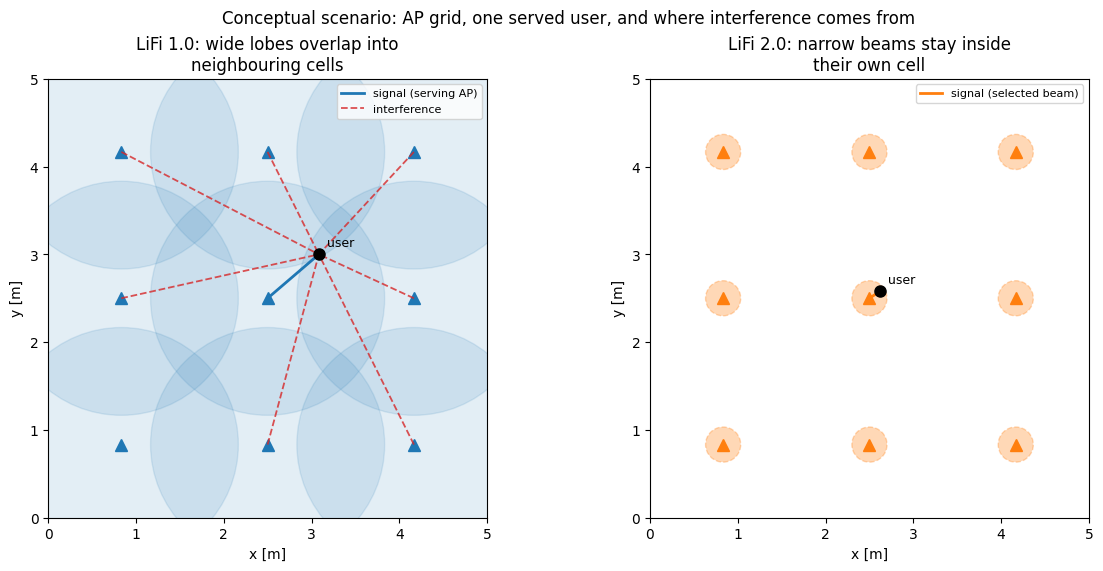

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.6), constrained_layout=True)

n_side = 3
room = 5.0
cell_pitch = room / n_side
ap_xy = np.linspace(cell_pitch / 2, room - cell_pitch / 2, n_side)
AX, AY = np.meshgrid(ap_xy, ap_xy)
ap_positions = np.column_stack([AX.ravel(), AY.ravel()])
serving_idx = 4  # center AP of the 3x3 grid
serving_ap = ap_positions[serving_idx]

# LiFi 1.0: wide, overlapping Lambertian 
ax = axes[0]
for x, y in ap_positions:
    ax.add_patch(plt.Circle((x, y), cell_pitch * 0.8, color="tab:blue", alpha=0.12))
    ax.plot(x, y, "^", color="tab:blue", ms=9)
user = serving_ap + np.array([cell_pitch * 0.35, cell_pitch * 0.3])
ax.plot(*user, "o", color="black", ms=8, zorder=5)
ax.annotate("user", user, textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.plot([serving_ap[0], user[0]], [serving_ap[1], user[1]], "-", color="tab:blue", lw=2, label="signal (serving AP)")
interference_labelled = False
for i, (x, y) in enumerate(ap_positions):
    if i != serving_idx and np.hypot(x - user[0], y - user[1]) < cell_pitch * 1.8:
        ax.plot([x, user[0]], [y, user[1]], "--", color="tab:red", lw=1.3, alpha=0.8,
                label=None if interference_labelled else "interference")
        interference_labelled = True
ax.set_xlim(0, room); ax.set_ylim(0, room); ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("LiFi 1.0: wide lobes overlap into\nneighbouring cells")
ax.legend(fontsize=8, loc="upper right")

# LiFi 2.0: tight, non-overlapping beam reach 
ax = axes[1]
beam_reach = cell_pitch * 0.12  # illustrative: how far a single narrow beam actually reaches
for x, y in ap_positions:
    ax.add_patch(plt.Circle((x, y), beam_reach, color="tab:orange", alpha=0.3, ec="tab:orange", lw=1, ls="--"))
    ax.plot(x, y, "^", color="tab:orange", ms=9)
user2 = serving_ap + np.array([beam_reach * 0.6, beam_reach * 0.4])
ax.plot(*user2, "o", color="black", ms=8, zorder=5)
ax.annotate("user", user2, textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.plot([serving_ap[0], user2[0]], [serving_ap[1], user2[1]], "-", color="tab:orange", lw=2, label="signal (selected beam)")
ax.set_xlim(0, room); ax.set_ylim(0, room); ax.set_aspect("equal")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title("LiFi 2.0: narrow beams stay inside\ntheir own cell")
ax.legend(fontsize=8, loc="upper right")

fig.suptitle("Conceptual scenario: AP grid, one served user, and where interference comes from")
plt.show()

### 2.5 Directivity: the two transmitters side by side


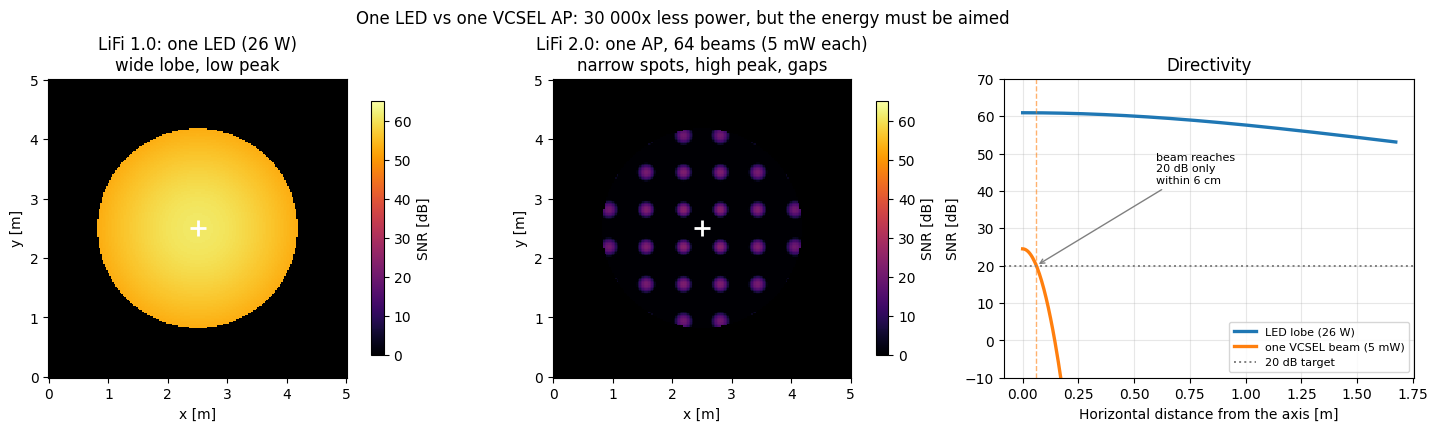

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)

# LED: one AP, received SNR map (power = its 2x2 illumination-driven value)
P2, _ = led_power(ap_lattice(2))
snr_led1 = (RHO*P2*H_led((2.5, 2.5)))**2/(N0*B_LED)
d0 = np.where(snr_led1 > 0, 10*np.log10(np.where(snr_led1 > 0, snr_led1, 1)), np.nan)
cm = plt.cm.inferno.copy(); cm.set_bad("black")
im = ax[0].pcolormesh(X, Y, d0, shading="auto", cmap=cm, vmin=0, vmax=65)
ax[0].set_title(f"LiFi 1.0: one LED ({P2:.0f} W)\nwide lobe, low peak")
fig.colorbar(im, ax=ax[0], label="SNR [dB]", shrink=0.85)

# VCSEL: one AP with an 8x8 beam grid over the whole room, 5 mW per beam
gb, _ = vcsel_ap_gains((2.5, 2.5), 1, 8)
snr_v1 = (RHO*P_VCSEL*gb)**2/(N0*B_VCSEL)
d1 = np.where(snr_v1 > 0, 10*np.log10(np.where(snr_v1 > 0, snr_v1, 1)), np.nan)
im = ax[1].pcolormesh(X, Y, d1, shading="auto", cmap=cm, vmin=0, vmax=65)
ax[1].set_title("LiFi 2.0: one AP, 64 beams (5 mW each)\nnarrow spots, high peak, gaps")
fig.colorbar(im, ax=ax[1], label="SNR [dB]", shrink=0.85)
for a in ax[:2]:
    a.plot(2.5, 2.5, "w+", ms=11, mew=2); a.set_aspect("equal")
    a.set_xlabel("x [m]"); a.set_ylabel("y [m]")

# radial cut: LED lobe vs a single VCSEL beam
r = np.linspace(0, 2.5, 500)
d = np.sqrt(r**2 + dz**2); th = np.arctan2(r, dz)
h_led = np.where(th <= PSI_C, (M_LED+1)*APD/(2*np.pi*d**2)*np.cos(th)**M_LED*np.cos(th)*G_CONC, 0)
wz = W0*np.sqrt(1 + (d/zR)**2)
h_v = np.where(th <= PSI_C, 2/(np.pi*wz**2)*np.exp(-2*r**2/wz**2)*APD*G_CONC, 0)
with np.errstate(divide="ignore"):
    s_led = 10*np.log10((RHO*P2*h_led)**2/(N0*B_LED))
    s_v = 10*np.log10((RHO*P_VCSEL*h_v)**2/(N0*B_VCSEL))
ax[2].plot(r, s_led, lw=2.4, color="tab:blue", label=f"LED lobe ({P2:.0f} W)")
ax[2].plot(r, s_v, lw=2.4, color="tab:orange", label="one VCSEL beam (5 mW)")
ax[2].axhline(GAMMA_TH_DB, color="gray", ls=":", lw=1.4, label=f"{GAMMA_TH_DB:.0f} dB target")
ax[2].axvline(r_th, color="tab:orange", ls="--", lw=1, alpha=.6)
ax[2].annotate(f"beam reaches\n{GAMMA_TH_DB:.0f} dB only\nwithin {r_th*100:.0f} cm",
               xy=(r_th, GAMMA_TH_DB), xytext=(0.6, 42), fontsize=8,
               arrowprops=dict(arrowstyle="->", lw=1, color="gray"))
ax[2].set_xlabel("Horizontal distance from the axis [m]"); ax[2].set_ylabel("SNR [dB]")
ax[2].set_ylim(-10, 70); ax[2].set_title("Directivity")
ax[2].legend(fontsize=8); ax[2].grid(alpha=.3)
fig.suptitle("One LED vs one VCSEL AP: 30 000x less power, but the energy must be aimed")
plt.show()

The LED covers the room in a wide, gentle lobe, which is good for lighting, but that same lobe will spill into every neighbouring cell once several APs are deployed, which is exactly the interference that must be analyzed.

The VCSEL puts far more SNR on target with 30,000x less power, but only within about 6 cm of each beam's axis, so it needs thousands of beams to blanket the same room. 

Directivity, in other words, is not free: it is paid for in emitters instead of watts.

### 2.6 Metrics

| Metric | Definition | Source |
|---|---|---|
| Coverage | % of room points with $\gamma \ge$ 20 dB | complement of the outage metric in `[RIS-VLC]` eq. (13) |
| Mean rate | average of $R(\mathbf{u})$ over the room | `[Capacity-Bound]` |
| Cell-edge rate | 5th percentile of $R(\mathbf{u})$, the worst-served users | standard measure, not specific to either paper |
| Area spectral efficiency | $N_{AP}\cdot\overline{R}/A_{room}$ [Mbit/s/m^2] | derived here, assuming one active user per AP |
| Energy per bit | $P_{total}/(N_{AP}\cdot\overline{R})$ [nJ/bit] | inverse of the energy-efficiency metric in `[RIS-VLC]` eq. (14) |

The last two metrics are what keep the comparison fair, since normalizing by area and by energy means a technology cannot win simply by using more APs or more watts.

### 2.7 Traceability of every decision

**Taken from the papers**

| Item | Value | Source |
|---|---|---|
| LED half-power semiangle -> Lambertian order | 80 deg -> $m$ = 0.40 | `[RIS-VLC]` Table III, eq. (1) |
| PD area $A_{PD}$ / responsivity $\rho$ | 1 cm^2 / 1 A/W | `[RIS-VLC]` Table III and `[VCSEL-Precoding]` Table I (they agree) |
| Receiver FoV $\Psi_c$ | 40 deg | `[RIS-VLC]` Table III (30/40/50 deg) |
| Concentrator $n$ -> gain $G$ | 1.5 -> 5.45 | `[VCSEL-Precoding]` eq. (8) |
| Bandwidths | 20 MHz / 2 GHz | `[RIS-VLC]` Table III / `[VCSEL-Precoding]` Table I |
| Noise PSD $N_0$ | 2.5e-20 W/Hz | `[RIS-VLC]` Table III |
| Luminous efficacy / lighting limits | 280 lm/W; 500 lux avg, 800 lux max, uniformity >= 0.5 | `[RIS-VLC]` Table III (C5, C6, C8), EN 12464-1 |
| VCSEL wavelength / array pitch | 950 nm / 10 um (emitters effectively co-located) | `[VCSEL-Precoding]` Table I |
| Beam waist $w_0$ | 5 um | `[Eye-Safety]` Figs. 7, 9, 13, 16-18 |
| Eye-safe power per emitter | 5 mW | `[Eye-Safety]` Fig. 18(b) at 950 nm, corroborated by `[VCSEL-70Gbps]` Fig. 1 |
| SINR threshold | 20 dB | inside the [10, 50] dB range of `[RIS-VLC]` Table III, which spans 2-PAM to 256-PAM at BER 1e-6 |
| Lambertian channel / SNR / outage / rate / energy efficiency / illuminance | eqs. (1), (12), (13), (14), (24)-(26) | `[RIS-VLC]` |
| Gaussian beam / concentrator / SINR / rate / cooperative broadcast | eqs. (2)-(8), (11), (12), Sec. II-B | `[VCSEL-Precoding]` |
| IM/DD rate bound | -- | `[Capacity-Bound]` |
| Eye-safety source classification ($\alpha_{min}$, $\alpha_{max}$, $C_6$) | 1.5 / 100 mrad | `[Eye-Safety]` Sec. III-C, Table 4 |
| 2x2 LED lattice / dense VCSEL grids | -- | `[RIS-VLC]` Sec. V / `[VCSEL-Precoding]` Sec. V |

**Own decisions/assumptions**

| Decision | Why | Effect |
|---|---|---|
| Room 5x5x3 m | keeps continuity with the single-cell notebook; sits between the papers' own rooms (4x4x3 and 3x3x5) | changes absolute numbers, not mechanisms |
| N x N AP lattice as the deployment variable | generalizes the 2x2 benchmark used in `[RIS-VLC]` | gives the natural design space for densification |
| Best-server (RSS) association | neither paper specifies one (they use TDMA or full cooperation instead) | a different rule would mostly move the cell borders |
| VCSEL AP modelled as a beam array with beam selection | a simplified stand-in for the precoding of `[VCSEL-Precoding]` | conservative, so the LiFi 2.0 results here are a lower bound |
| APs get independent eye-safety budgets; emitters inside one AP share a single budget | follows from the subtense-based classification in `[Eye-Safety]`, though no explicit multi-AP rule is given there | conservative, since the $C_6$ relaxation would allow more array power |
| Interference under beam selection modelled as the average over the interferer's beams | interferers aim at their own unknown users, assumed uniform within each cell | a mean, not a worst case - the most debatable assumption in the notebook (Section 10) |
| Local cooperation cluster = APs within 3 dB of the best | a simple, scalable clustering rule; the papers define none | the global-cooperation case still bounds any other choice |
| One active user per AP | the simplest possible scheduling assumption | multi-user scheduling within a cell is not modelled |

---

## 3. Case 1: equal coverage target

The target is 95% of the room above 20 dB SINR. The question is: what is the minimum deployment each technology needs to reach it?

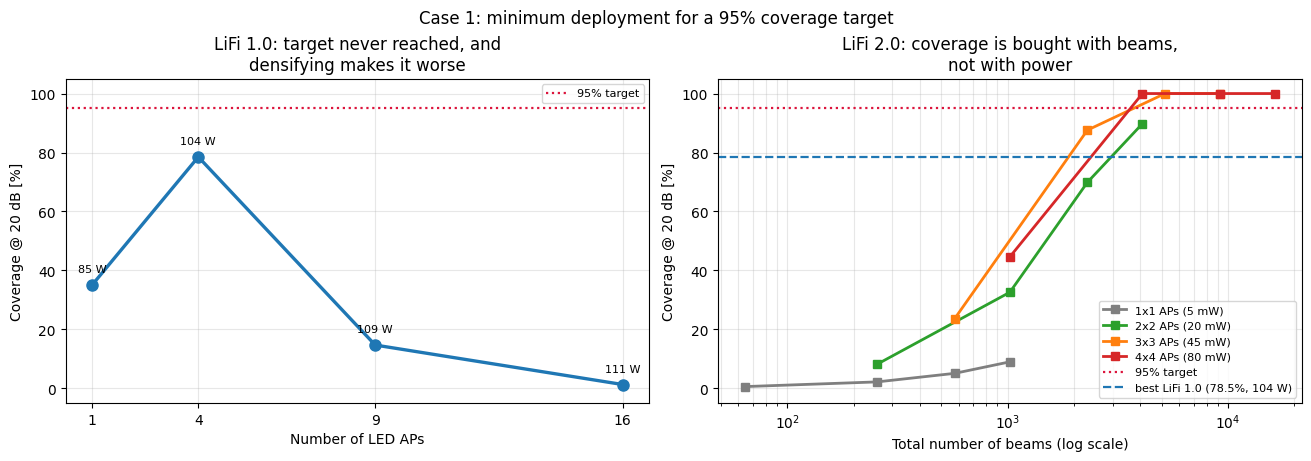

LiFi 1.0: target NOT met by any deployment (best: 2x2 -> 78.5% with 103.9 W)

LiFi 2.0 deployments meeting the target:
   LiFi 2.0 -- 3x3 APs x 576 beams        5184 beams     45 mW  -> 100.0%
   LiFi 2.0 -- 3x3 APs x 1024 beams       9216 beams     45 mW  -> 100.0%
   LiFi 2.0 -- 4x4 APs x 256 beams        4096 beams     80 mW  -> 100.0%
   LiFi 2.0 -- 4x4 APs x 576 beams        9216 beams     80 mW  -> 100.0%
   LiFi 2.0 -- 4x4 APs x 1024 beams      16384 beams     80 mW  -> 100.0%


In [4]:
led_rows = []
for n in [1, 2, 3, 4]:
    s, Pt, nc, Ev = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, f"LiFi 1.0 -- {n}x{n} LED APs")
    r["Lighting"] = "OK" if Ev.max() <= E_MAX else f"peak {Ev.max():.0f} lux > 800"
    r["95% met?"] = "YES" if r["Coverage [%]"] >= COV_TARGET else "no"
    led_rows.append(r)
led_df = pd.DataFrame(led_rows)

v_rows = []
for n in [1, 2, 3, 4]:
    for m in [8, 16, 24, 32]:
        s, Pt, nc = evaluate_vcsel(n, m)
        r, _ = metrics(s, B_VCSEL, Pt, nc, f"LiFi 2.0 -- {n}x{n} APs x {m*m} beams",
                       **{"Beams/AP": m*m, "Total beams": nc*m*m})
        r["95% met?"] = "YES" if r["Coverage [%]"] >= COV_TARGET else "no"
        v_rows.append(r)
vdf = pd.DataFrame(v_rows)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
# LiFi 1.0: coverage vs number of APs
ax[0].plot(led_df.APs, led_df["Coverage [%]"], "o-", color="tab:blue", lw=2.4, ms=8)
ax[0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.6, label="95% target")
for _, r in led_df.iterrows():
    ax[0].annotate(f"{r['P total [W]']:.0f} W", (r.APs, r["Coverage [%]"]),
                   textcoords="offset points", xytext=(0, 9), ha="center", fontsize=8)
ax[0].set_xlabel("Number of LED APs"); ax[0].set_ylabel("Coverage @ 20 dB [%]")
ax[0].set_xticks([1, 4, 9, 16]); ax[0].set_ylim(-5, 105)
ax[0].set_title("LiFi 1.0: target never reached, and\ndensifying makes it worse")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

# LiFi 2.0: coverage vs total beams, one curve per AP count
for n, col in zip([1, 2, 3, 4], ["tab:gray", "tab:green", "tab:orange", "tab:red"]):
    sub = vdf[vdf.APs == n*n]
    ax[1].plot(sub["Total beams"], sub["Coverage [%]"], "s-", color=col, lw=2, ms=6,
               label=f"{n}x{n} APs ({n*n*5} mW)")
ax[1].axhline(COV_TARGET, color="crimson", ls=":", lw=1.6, label="95% target")
ax[1].axhline(led_df["Coverage [%]"].max(), color="tab:blue", ls="--", lw=1.6,
              label="best LiFi 1.0 (78.5%, 104 W)")
ax[1].set_xscale("log"); ax[1].set_xlabel("Total number of beams (log scale)")
ax[1].set_ylabel("Coverage @ 20 dB [%]"); ax[1].set_ylim(-5, 105)
ax[1].set_title("LiFi 2.0: coverage is bought with beams,\nnot with power")
ax[1].legend(fontsize=8); ax[1].grid(alpha=.3, which="both")
fig.suptitle("Case 1: minimum deployment for a 95% coverage target")
plt.show()

ok = vdf[vdf["95% met?"] == "YES"]
print("LiFi 1.0: target NOT met by any deployment (best: 2x2 -> 78.5% with 103.9 W)")
print("\nLiFi 2.0 deployments meeting the target:")
for _, r in ok.iterrows():
    print(f"   {r['Deployment']:36s} {r['Total beams']:6d} beams  {r['P total [W]']*1000:5.0f} mW  "
          f"-> {r['Coverage [%]']:5.1f}%")

In [5]:
vdf[["Deployment", "APs", "Beams/AP", "Total beams", "P total [W]", "Coverage [%]",
     "Mean rate [Mbit/s]", "Energy/bit [nJ]", "95% met?"]]

,Deployment,APs,Beams/AP,Total beams,P total [W],Coverage [%],Mean rate [Mbit/s],Energy/bit [nJ],95% met?
0,LiFi 2.0 -- 1x1 APs x 64 beams,1,64,64,0.005,0.6,212.3,0.0236,no
1,LiFi 2.0 -- 1x1 APs x 256 beams,1,256,256,0.005,2.2,808.9,0.0062,no
2,LiFi 2.0 -- 1x1 APs x 576 beams,1,576,576,0.005,5.1,1428.0,0.0035,no
3,LiFi 2.0 -- 1x1 APs x 1024 beams,1,1024,1024,0.005,9.0,1729.1,0.0029,no
4,LiFi 2.0 -- 2x2 APs x 64 beams,4,64,256,0.020,8.2,2291.7,0.0022,no
5,LiFi 2.0 -- 2x2 APs x 256 beams,4,256,1024,0.020,32.6,4997.7,0.0010,no
6,LiFi 2.0 -- 2x2 APs x 576 beams,4,576,2304,0.020,69.9,5692.8,0.0009,no
7,LiFi 2.0 -- 2x2 APs x 1024 beams,4,1024,4096,0.020,89.8,5939.6,0.0008,no
8,LiFi 2.0 -- 3x3 APs x 64 beams,9,64,576,0.045,23.7,4177.2,0.0012,no
9,LiFi 2.0 -- 3x3 APs x 256 beams,9,256,2304,0.045,87.6,5988.1,0.0008,no


* **LiFi 1.0 never reaches the 95% target, and densifying only makes it worse:** coverage goes 78.5% (2x2) -> 14.7% (3x3) -> 1.3% (4x4). Once the AP spacing drops below the FoV footprint (1.68 m), every user starts seeing several LEDs of similar strength, and the SINR collapses at the cell borders. More power cannot fix this, since signal and interference scale together.

* **LiFi 2.0 reaches 100% coverage with only 45-80 mW**, against the LED's 104 W, but it needs thousands of beams to do it, close to the roughly 2100 geometric minimum implied by Figure 1.

* **Coverage is bought with beams, not watts:** the right-hand panel shows that at 4 APs, going from 64 to 1024 beams takes coverage from 8.2% to 89.8% at exactly the same 20 mW.

## 4. Case 2: equal infrastructure

This case fixes the same number of APs in the same positions for both technologies: but equal infrastructure does not mean equal power.

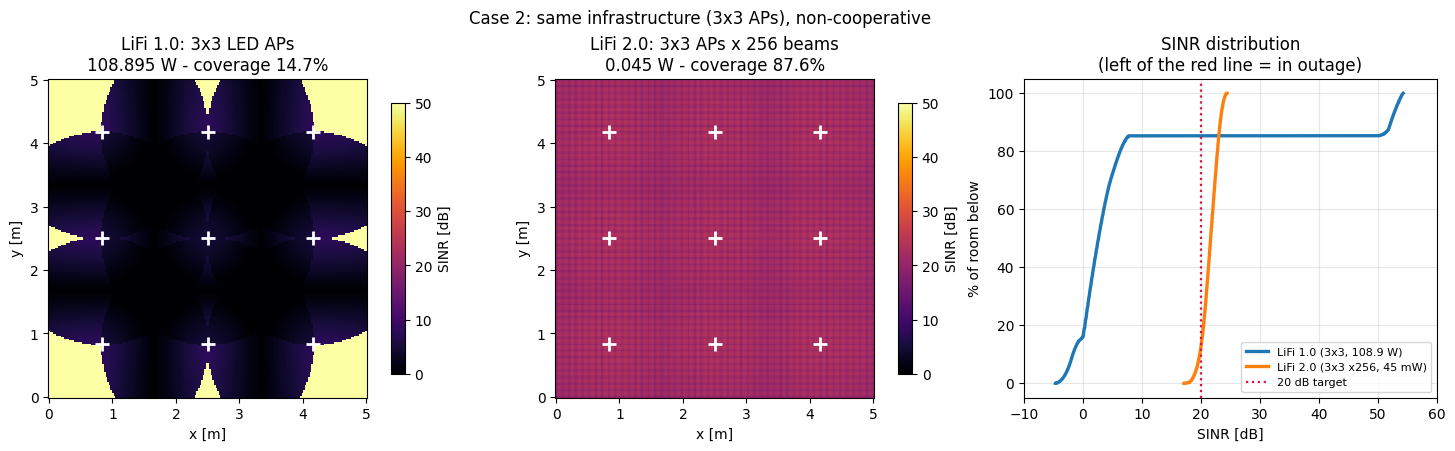

,Deployment,APs,P total [W],Coverage [%],Mean rate [Mbit/s],Cell-edge rate [Mbit/s],ASE [Mbit/s/m2],Energy/bit [nJ]
0,2x2 - LiFi 1.0 (LED),4,103.884,78.5,143.2,6.0,22.9,181.3559
1,2x2 - LiFi 2.0 (256 beams/AP),4,0.020,32.6,4997.7,3527.8,799.6,0.0010
2,3x3 - LiFi 1.0 (LED),9,108.895,14.7,30.9,3.1,11.1,391.2410
3,3x3 - LiFi 2.0 (256 beams/AP),9,0.045,87.6,5988.1,5231.8,2155.7,0.0008
4,4x4 - LiFi 1.0 (LED),16,110.574,1.3,6.5,2.4,4.1,1068.2005
5,4x4 - LiFi 2.0 (256 beams/AP),16,0.080,100.0,6378.5,5920.0,4082.2,0.0008


In [6]:
iso = []
for n in [2, 3, 4]:
    s, P, nc, _ = evaluate_led(n)
    r, _ = metrics(s, B_LED, P, nc, f"{n}x{n} - LiFi 1.0 (LED)"); iso.append(r)
    s, P, nc = evaluate_vcsel(n, 16)
    r, _ = metrics(s, B_VCSEL, P, nc, f"{n}x{n} - LiFi 2.0 (256 beams/AP)"); iso.append(r)
iso_df = pd.DataFrame(iso)

s_led, P_led, _, _ = evaluate_led(3)
s_v, P_v, _ = evaluate_vcsel(3, 16)
cm = plt.cm.inferno.copy(); cm.set_bad("black")
fig = plt.figure(figsize=(15, 4.4), constrained_layout=True)
gs = fig.add_gridspec(1, 3)
for k, (S, ttl, P, cov) in enumerate([
        (s_led, "LiFi 1.0: 3x3 LED APs", P_led, 100*np.mean(s_led >= GAMMA_TH)),
        (s_v, "LiFi 2.0: 3x3 APs x 256 beams", P_v, 100*np.mean(s_v >= GAMMA_TH))]):
    ax = fig.add_subplot(gs[0, k])
    dB = np.where(S > 0, 10*np.log10(np.where(S > 0, S, 1)), np.nan)
    im = ax.pcolormesh(X, Y, dB, shading="auto", cmap=cm, vmin=0, vmax=50)
    ax.plot(ap_lattice(3)[:, 0], ap_lattice(3)[:, 1], "w+", ms=10, mew=2)
    ax.set_title(f"{ttl}\n{P:.3f} W - coverage {cov:.1f}%")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_aspect("equal")
    fig.colorbar(im, ax=ax, label="SINR [dB]", shrink=0.85)

# CDF panel
ax = fig.add_subplot(gs[0, 2])
for S, lb, c in [(s_led, "LiFi 1.0 (3x3, 108.9 W)", "tab:blue"),
                 (s_v, "LiFi 2.0 (3x3 x256, 45 mW)", "tab:orange")]:
    d = np.sort(10*np.log10(np.maximum(S.ravel(), 1e-12)))
    ax.plot(d, np.linspace(0, 100, d.size), lw=2.4, color=c, label=lb)
ax.axvline(GAMMA_TH_DB, color="crimson", ls=":", lw=1.6, label="20 dB target")
ax.set_xlim(-10, 60); ax.set_xlabel("SINR [dB]"); ax.set_ylabel("% of room below")
ax.set_title("SINR distribution\n(left of the red line = in outage)")
ax.legend(fontsize=8); ax.grid(alpha=.3)
fig.suptitle("Case 2: same infrastructure (3x3 APs), non-cooperative")
plt.show()

iso_df[["Deployment", "APs", "P total [W]", "Coverage [%]", "Mean rate [Mbit/s]",
        "Cell-edge rate [Mbit/s]", "ASE [Mbit/s/m2]", "Energy/bit [nJ]"]]

At 3x3 APs, LiFi 2.0 reaches 87.6% coverage and 6.0 Gbit/s with only 45 mW, while LiFi 1.0 reaches 14.7% coverage and 31 Mbit/s with 108.9 W. The maps show why, and they show that the two technologies fail in opposite ways.

* **The LED map is bright inside each cell and pitch-black along every border** - interference-limited pattern. The CDF confirms it: a large fraction of the room sits far below the target.

* **The VCSEL map is a fine texture of bright spots.** A 12 cm beam never reaches the neighbouring cell, so there is almost nothing left to interfere with. Its dark gaps are a coverage problem, curable with more beams, rather than an interference problem.

The LED's low directivity, exactly what makes it a good lamp, is the same property that makes it a poor multi-cell transmitter.

## 5. Case 3: cross-equivalence

This case runs the reverse reasoning in both directions: what would each technology need to match the other's service level? Three metrics have to be matched at once for the comparison to count: coverage, mean rate, and cell-edge rate.

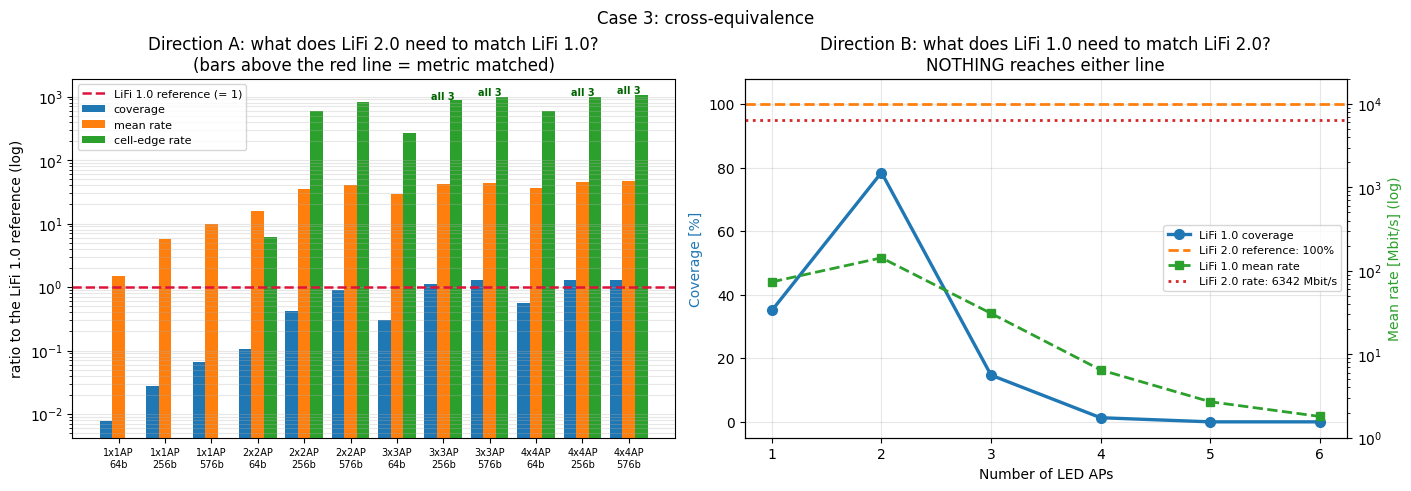

Cheapest LiFi 2.0 config matching ALL THREE metrics of the LED 2x2 reference:
   3x3 APs x 256 beams  ->  2304 beams, 45 mW
   coverage 87.6% (ref 78.5%), mean rate 5988 (ref 143), cell-edge 5232 (ref 6) Mbit/s
   power ratio: 2309x LESS optical power than the LED

Reverse direction: best LED coverage = 78.5% vs 100% required -> IMPOSSIBLE
                   best LED rate = 143.2 vs 6342 Mbit/s -> short by 44x, set by BANDWIDTH (20 MHz vs 2 GHz)


In [7]:
# Direction A: LiFi 1.0 reference = 2x2 LEDs (the deployment its lighting requires) 
s_ref, P_ref, nc_ref, _ = evaluate_led(2)
ref, _ = metrics(s_ref, B_LED, P_ref, nc_ref, "REFERENCE")

rowsA = []
for n in [1, 2, 3, 4]:
    for m in [8, 16, 24]:
        s, Pt, nc = evaluate_vcsel(n, m)
        r, _ = metrics(s, B_VCSEL, Pt, nc, f"{n}x{n} APs x {m*m} beams", **{"Total beams": nc*m*m})
        r["cov"] = r["Coverage [%]"] / ref["Coverage [%]"]
        r["rate"] = r["Mean rate [Mbit/s]"] / ref["Mean rate [Mbit/s]"]
        r["edge"] = r["Cell-edge rate [Mbit/s]"] / max(ref["Cell-edge rate [Mbit/s]"], 1e-9)
        r["ALL 3?"] = "*** YES ***" if min(r["cov"], r["rate"], r["edge"]) >= 1 else ""
        rowsA.append(r)
dfA = pd.DataFrame(rowsA)

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8), constrained_layout=True)
x = np.arange(len(dfA)); w = 0.27
for k, (col, lb, c) in enumerate([("cov", "coverage", "tab:blue"),
                                  ("rate", "mean rate", "tab:orange"),
                                  ("edge", "cell-edge rate", "tab:green")]):
    ax[0].bar(x + (k-1)*w, dfA[col], w, label=lb, color=c)
ax[0].axhline(1, color="crimson", ls="--", lw=1.8, label="LiFi 1.0 reference (= 1)")
ax[0].set_yscale("log"); ax[0].set_xticks(x)
ax[0].set_xticklabels([d.replace(" APs x ", "AP\n").replace(" beams", "b") for d in dfA.Deployment],
                      rotation=0, fontsize=7)
ax[0].set_ylabel("ratio to the LiFi 1.0 reference (log)")
ax[0].set_title("Direction A: what does LiFi 2.0 need to match LiFi 1.0?\n"
                "(bars above the red line = metric matched)")
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3, axis="y", which="both")
for i, ok in enumerate(dfA["ALL 3?"]):
    if ok:
        ax[0].annotate("all 3", (i, 1.05*dfA[["cov", "rate", "edge"]].iloc[i].max()),
                       ha="center", fontsize=7, color="darkgreen", weight="bold")

# Direction B: LiFi 2.0 reference = 3x3 x576 (its cheapest 100% deployment) 
s_v, P_v, nc_v = evaluate_vcsel(3, 24)
refv, _ = metrics(s_v, B_VCSEL, P_v, nc_v, "REF")
ns = [1, 2, 3, 4, 5, 6]
led_cov, led_rate = [], []
for n in ns:
    s, Pt, nc, _ = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, "")
    led_cov.append(r["Coverage [%]"]); led_rate.append(r["Mean rate [Mbit/s]"])
ax2 = ax[1]
ax2.plot(ns, led_cov, "o-", color="tab:blue", lw=2.4, ms=7, label="LiFi 1.0 coverage")
ax2.axhline(refv["Coverage [%]"], color="tab:orange", ls="--", lw=2,
            label=f"LiFi 2.0 reference: {refv['Coverage [%]']:.0f}%")
ax2.set_xlabel("Number of LED APs"); ax2.set_ylabel("Coverage [%]", color="tab:blue")
ax2.set_ylim(-5, 108); ax2.set_xticks(ns); ax2.grid(alpha=.3)
axb = ax2.twinx()
axb.semilogy(ns, led_rate, "s--", color="tab:green", lw=2, ms=6, label="LiFi 1.0 mean rate")
axb.axhline(refv["Mean rate [Mbit/s]"], color="tab:red", ls=":", lw=2,
            label=f"LiFi 2.0 rate: {refv['Mean rate [Mbit/s]']:.0f} Mbit/s")
axb.set_ylabel("Mean rate [Mbit/s] (log)", color="tab:green")
axb.set_ylim(1, 2e4)
h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = axb.get_legend_handles_labels()
ax2.legend(h1+h2, l1+l2, fontsize=8, loc="center right")
ax2.set_title("Direction B: what does LiFi 1.0 need to match LiFi 2.0?\n"
              "NOTHING reaches either line")
fig.suptitle("Case 3: cross-equivalence")
plt.show()

best = dfA[dfA["ALL 3?"] != ""].sort_values("Total beams").iloc[0]
print(f"Cheapest LiFi 2.0 config matching ALL THREE metrics of the LED 2x2 reference:")
print(f"   {best['Deployment']}  ->  {best['Total beams']} beams, {best['P total [W]']*1000:.0f} mW")
print(f"   coverage {best['Coverage [%]']}% (ref {ref['Coverage [%]']}%), "
      f"mean rate {best['Mean rate [Mbit/s]']:.0f} (ref {ref['Mean rate [Mbit/s]']:.0f}), "
      f"cell-edge {best['Cell-edge rate [Mbit/s]']:.0f} (ref {ref['Cell-edge rate [Mbit/s]']:.0f}) Mbit/s")
print(f"   power ratio: {P_ref/best['P total [W]']:.0f}x LESS optical power than the LED\n")
print(f"Reverse direction: best LED coverage = {max(led_cov):.1f}% vs {refv['Coverage [%]']:.0f}% required -> IMPOSSIBLE")
print(f"                   best LED rate = {max(led_rate):.1f} vs {refv['Mean rate [Mbit/s]']:.0f} Mbit/s "
      f"-> short by {refv['Mean rate [Mbit/s]']/max(led_rate):.0f}x, set by BANDWIDTH (20 MHz vs 2 GHz)")

**Direction A: LiFi 2.0 matching LiFi 1.0.** The three metrics turn out to be matched at very different costs, and the ordering between them is itself the finding. Mean rate is matched by a single AP with just 64 beams, using 5 mW against the LED's 104 W, since rate mostly comes from bandwidth and is essentially free to reach. Cell-edge rate needs a handful more beams. Coverage is the hard one, and it is what ends up setting the deployment size: the cheapest configuration that beats the LED reference on all three metrics at once is 3x3 APs with 256 beams each (2304 beams total), using 45 mW -- a power budget about 2300x smaller than the LED's.

**Direction B: LiFi 1.0 matching LiFi 2.0.** No solution exists in this direction. On coverage, the LED's ceiling is 78.5% and densifying only makes it worse. On rate, since $R \propto B$, the 20 MHz vs 2 GHz gap becomes a 44x rate gap that no number of LEDs or added watts can close, because bandwidth is not something a deployment can change.

The equivalence between the two technologies is therefore asymmetric: LiFi 2.0 can always emulate LiFi 1.0, and can do so a thousand times more cheaply in energy, while LiFi 1.0 can never emulate LiFi 2.0, since it is limited by two things no deployment choice can change: bandwidth and directivity.

## 6. Case 4: scalability and densification

This case asks whether adding infrastructure actually adds capacity, which is the question that could decide whether either technology is viable for a 6G-style ultra-dense deployment.

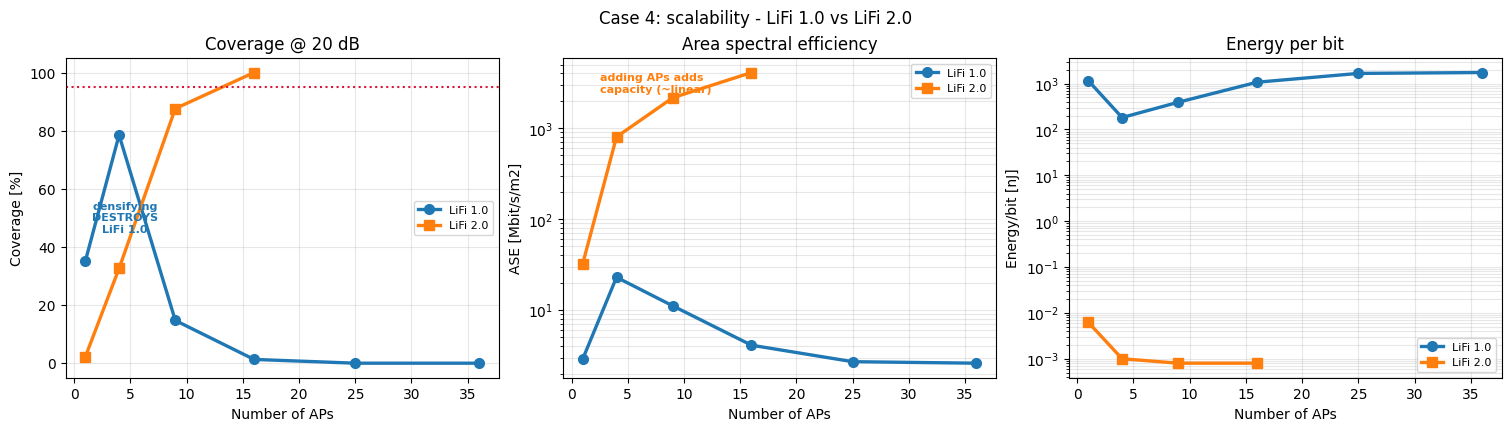

,Deployment,APs,P total [W],Coverage [%],Mean rate [Mbit/s],ASE [Mbit/s/m2],Energy/bit [nJ]
0,LiFi 1.0 -- 1x1,1,84.882,35.1,73.7,2.9,1151.3957
1,LiFi 1.0 -- 2x2,4,103.884,78.5,143.2,22.9,181.3559
2,LiFi 1.0 -- 3x3,9,108.895,14.7,30.9,11.1,391.2410
3,LiFi 1.0 -- 4x4,16,110.574,1.3,6.5,4.1,1068.2005
4,LiFi 1.0 -- 5x5,25,111.320,0.0,2.7,2.7,1662.1118
5,LiFi 1.0 -- 6x6,36,111.717,0.0,1.8,2.6,1737.1498
6,LiFi 2.0 -- 1x1 (256 beams/AP),1,0.005,2.2,808.9,32.4,0.0062
7,LiFi 2.0 -- 2x2 (256 beams/AP),4,0.020,32.6,4997.7,799.6,0.0010
8,LiFi 2.0 -- 3x3 (256 beams/AP),9,0.045,87.6,5988.1,2155.7,0.0008
9,LiFi 2.0 -- 4x4 (256 beams/AP),16,0.080,100.0,6378.5,4082.2,0.0008


In [8]:
dens = []
for n in [1, 2, 3, 4, 5, 6]:
    s, Pt, nc, _ = evaluate_led(n)
    r, _ = metrics(s, B_LED, Pt, nc, f"LiFi 1.0 -- {n}x{n}"); dens.append(r)
for n in [1, 2, 3, 4]:
    s, Pt, nc = evaluate_vcsel(n, 16)
    r, _ = metrics(s, B_VCSEL, Pt, nc, f"LiFi 2.0 -- {n}x{n} (256 beams/AP)"); dens.append(r)
ddf = pd.DataFrame(dens)
L = ddf[ddf.Deployment.str.contains("1.0")]; V = ddf[ddf.Deployment.str.contains("2.0")]

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2), constrained_layout=True)
for a, key, ttl, logy in [(ax[0], "Coverage [%]", "Coverage @ 20 dB", False),
                          (ax[1], "ASE [Mbit/s/m2]", "Area spectral efficiency", True),
                          (ax[2], "Energy/bit [nJ]", "Energy per bit", True)]:
    plot = a.semilogy if logy else a.plot
    plot(L.APs, L[key], "o-", color="tab:blue", lw=2.4, ms=7, label="LiFi 1.0")
    plot(V.APs, V[key], "s-", color="tab:orange", lw=2.4, ms=7, label="LiFi 2.0")
    a.set_xlabel("Number of APs"); a.set_ylabel(key); a.set_title(ttl)
    a.legend(fontsize=8); a.grid(alpha=.3, which="both")
ax[0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.5); ax[0].set_ylim(-5, 105)
ax[0].annotate("densifying\nDESTROYS\nLiFi 1.0", (4.5, 45), fontsize=8, color="tab:blue",
               ha="center", weight="bold")
ax[1].annotate("adding APs adds\ncapacity (~linear)", (2.5, 2500), fontsize=8,
               color="tab:orange", weight="bold")
fig.suptitle("Case 4: scalability - LiFi 1.0 vs LiFi 2.0")
plt.show()

ddf[["Deployment", "APs", "P total [W]", "Coverage [%]", "Mean rate [Mbit/s]",
     "ASE [Mbit/s/m2]", "Energy/bit [nJ]"]]

The two technologies scale in opposite directions:

* **LiFi 1.0 does not scale.** Coverage falls as density increases (78.5% -> 14.7% -> 1.3%), since every new LED is simply a new interferer inside everybody's FoV. Its area spectral efficiency peaks at 2x2 and then drops, and its energy per bit gets worse rather than better. Without coordination, it becomes interference-limited at a very low density, and any further investment in APs only makes things worse.

* **LiFi 2.0 scales cleanly.** Coverage rises to 100%, and the area spectral efficiency grows almost linearly (32 -> 800 -> 2156 -> 4082 Mbit/s/m^2), because narrow beams keep the cells isolated, so an added AP adds capacity without taking it away from its neighbours.

A 6G indoor network has to add capacity by densifying, and the two technologies handle that requirement very differently: LiFi 1.0 can only densify if its interference is actively managed, while LiFi 2.0 handles it intrinsically. The next section tests the first half of that claim.

## 7. Cooperative networks

LiFi 1.0 collapses under densification because of co-channel interference, and the classical solution for that is to make neighbouring APs cooperate, transmitting the same signal to the same user so that the interference is not just suppressed but turned into useful signal. Both reference papers point in this direction: `[RIS-VLC]` (Sec. I) cites cooperative techniques for attocell networks, and `[VCSEL-Precoding]` builds its entire system around a cooperative broadcast model (Sec. II-B).

With perfect synchronization, the optical amplitudes add before the square-law detection, so the useful signal becomes the square of the sum rather than a sum of squares (the same structure as `[VCSEL-Precoding]` eqs. (9)-(11)):

$$\gamma_{\text{coop}} = \frac{\left(\sum_{i \in \mathcal{C}} \rho P_i H_i\right)^{2}}{N_0 B + \sum_{i \notin \mathcal{C}} \left(\rho P_i H_i\right)^{2}}$$

Cooperating APs move from the denominator into the numerator, which is exactly why the gain from cooperation is largest where the non-cooperative SINR was worst: at the cell borders.

Two scenarios are compared. In the local case, only the APs within 3 dB of the best one cooperate, a simple clustering rule chosen to be scalable. In the global case, every AP cooperates, so interference vanishes by construction and this becomes a theoretical ceiling rather than something deployable.

These results assume perfect synchronization, perfect channel state information, and no backhaul cost, so they should be read as an upper bound on what cooperation can realistically deliver.

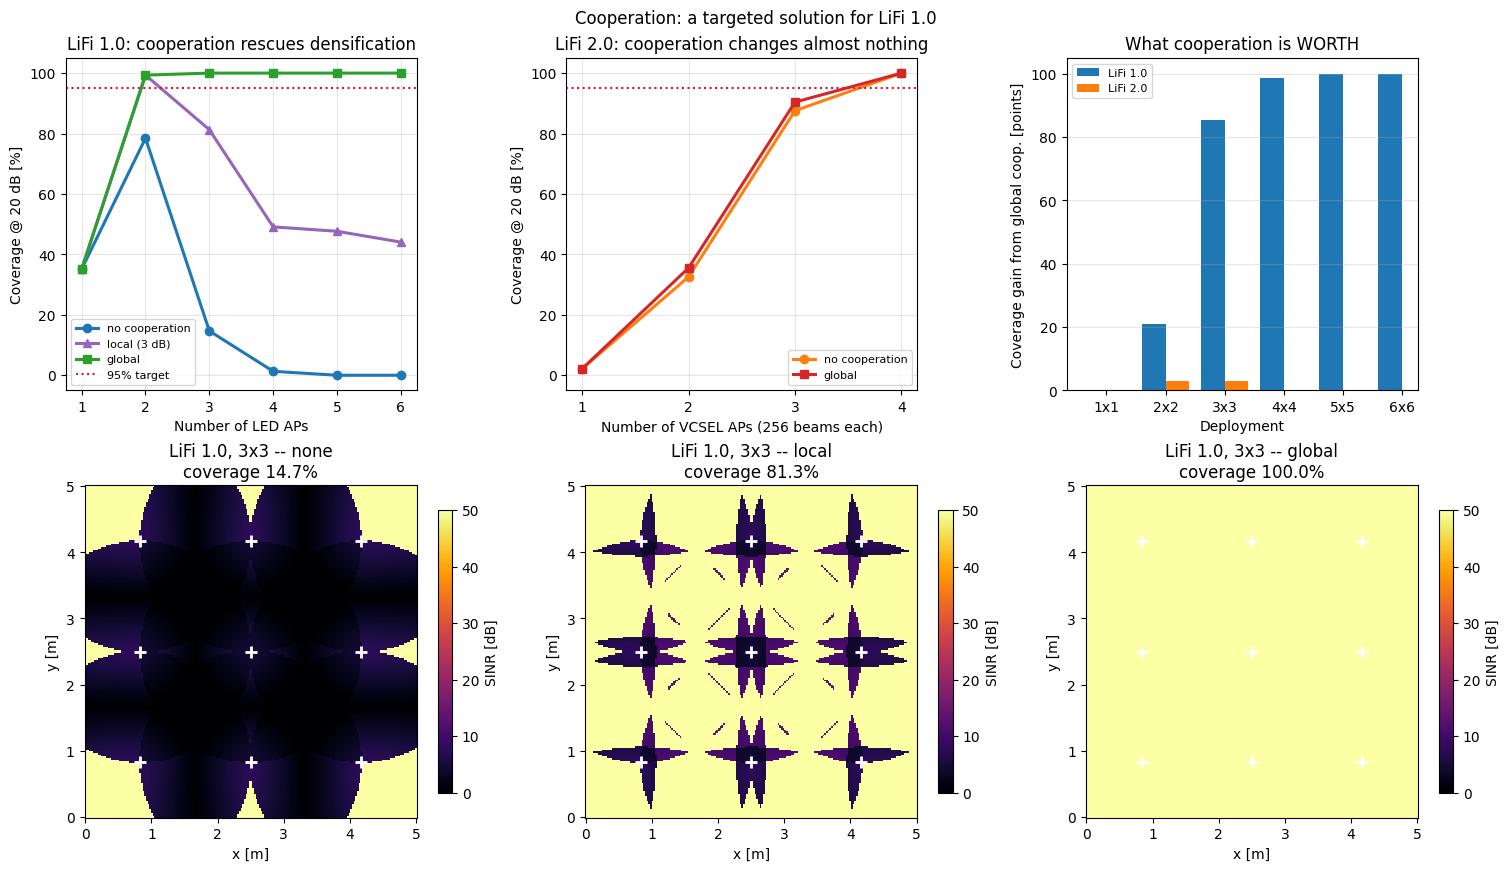

Coverage gain from GLOBAL cooperation:
  LiFi 1.0 1x1:  35.1% ->  35.1%  (  +0.0 points)
  LiFi 1.0 2x2:  78.5% ->  99.3%  ( +20.9 points)
  LiFi 1.0 3x3:  14.7% -> 100.0%  ( +85.3 points)
  LiFi 1.0 4x4:   1.3% -> 100.0%  ( +98.7 points)
  LiFi 1.0 5x5:   0.0% -> 100.0%  (+100.0 points)
  LiFi 1.0 6x6:   0.0% -> 100.0%  (+100.0 points)
  LiFi 2.0 1x1:   2.2% ->   2.2%  (  +0.0 points)
  LiFi 2.0 2x2:  32.6% ->  35.5%  (  +3.0 points)
  LiFi 2.0 3x3:  87.6% ->  90.4%  (  +2.8 points)
  LiFi 2.0 4x4: 100.0% -> 100.0%  (  +0.0 points)


In [9]:
ns_l, ns_v = [1, 2, 3, 4, 5, 6], [1, 2, 3, 4]
cl = {cp: [100*np.mean(evaluate_led(n, coop=cp)[0] >= GAMMA_TH) for n in ns_l]
      for cp in ["none", "local", "global"]}
cv = {cp: [100*np.mean(evaluate_vcsel(n, 16, coop=cp)[0] >= GAMMA_TH) for n in ns_v]
      for cp in ["none", "global"]}

fig = plt.figure(figsize=(15, 8.6), constrained_layout=True)
gs = fig.add_gridspec(2, 3)

# top-left: LED coverage vs density, 3 regimes
a = fig.add_subplot(gs[0, 0])
for cp, st, lb, c in [("none", "o-", "no cooperation", "tab:blue"),
                      ("local", "^-", "local (3 dB)", "tab:purple"),
                      ("global", "s-", "global", "tab:green")]:
    a.plot(ns_l, cl[cp], st, lw=2.2, ms=6, color=c, label=lb)
a.axhline(COV_TARGET, color="crimson", ls=":", lw=1.5, label="95% target")
a.set_xlabel("Number of LED APs"); a.set_ylabel("Coverage @ 20 dB [%]")
a.set_xticks(ns_l); a.set_ylim(-5, 105); a.legend(fontsize=8); a.grid(alpha=.3)
a.set_title("LiFi 1.0: cooperation rescues densification")

# top-middle: VCSEL
a = fig.add_subplot(gs[0, 1])
for cp, st, lb, c in [("none", "o-", "no cooperation", "tab:orange"),
                      ("global", "s-", "global", "tab:red")]:
    a.plot(ns_v, cv[cp], st, lw=2.2, ms=6, color=c, label=lb)
a.axhline(COV_TARGET, color="crimson", ls=":", lw=1.5)
a.set_xlabel("Number of VCSEL APs (256 beams each)"); a.set_ylabel("Coverage @ 20 dB [%]")
a.set_xticks(ns_v); a.set_ylim(-5, 105); a.legend(fontsize=8); a.grid(alpha=.3)
a.set_title("LiFi 2.0: cooperation changes almost nothing")

# top-right: gain bar chart
a = fig.add_subplot(gs[0, 2])
gains_l = [b-x for x, b in zip(cl["none"], cl["global"])]
gains_v = [b-x for x, b in zip(cv["none"], cv["global"])]
a.bar(np.arange(len(ns_l))-0.2, gains_l, 0.4, color="tab:blue", label="LiFi 1.0")
a.bar(np.arange(len(ns_v))+0.2, gains_v, 0.4, color="tab:orange", label="LiFi 2.0")
a.set_xticks(np.arange(len(ns_l))); a.set_xticklabels([f"{n}x{n}" for n in ns_l])
a.set_xlabel("Deployment"); a.set_ylabel("Coverage gain from global coop. [points]")
a.set_title("What cooperation is WORTH"); a.legend(fontsize=8); a.grid(alpha=.3, axis="y")

# bottom: LED 3x3 SINR maps, before and after cooperation
cm = plt.cm.inferno.copy(); cm.set_bad("black")
for k, cp in enumerate(["none", "local", "global"]):
    s, P, nc, _ = evaluate_led(3, coop=cp)
    a = fig.add_subplot(gs[1, k])
    dB = np.where(s > 0, 10*np.log10(np.where(s > 0, s, 1)), np.nan)
    im = a.pcolormesh(X, Y, dB, shading="auto", cmap=cm, vmin=0, vmax=50)
    a.plot(ap_lattice(3)[:, 0], ap_lattice(3)[:, 1], "w+", ms=9, mew=2)
    a.set_title(f"LiFi 1.0, 3x3 -- {cp}\ncoverage {100*np.mean(s >= GAMMA_TH):.1f}%")
    a.set_xlabel("x [m]"); a.set_ylabel("y [m]"); a.set_aspect("equal")
    fig.colorbar(im, ax=a, label="SINR [dB]", shrink=0.85)
fig.suptitle("Cooperation: a targeted solution for LiFi 1.0")
plt.show()

print("Coverage gain from GLOBAL cooperation:")
for n, a_, b_ in zip(ns_l, cl["none"], cl["global"]):
    print(f"  LiFi 1.0 {n}x{n}: {a_:5.1f}% -> {b_:5.1f}%  ({b_-a_:+6.1f} points)")
for n, a_, b_ in zip(ns_v, cv["none"], cv["global"]):
    print(f"  LiFi 2.0 {n}x{n}: {a_:5.1f}% -> {b_:5.1f}%  ({b_-a_:+6.1f} points)")

* **For LiFi 1.0, cooperation is transformative.** The bottom row shows it directly: the black interference bands between cells simply disappear. Coverage goes from 14.7% to 100% at 3x3, and from 1.3% to 100% at 4x4 so cooperation is what unlocks densification for LiFi 1.0 in the first place.

* **Local cooperation (3 dB) captures most of the benefit at low density, but progressively less as the network gets denser** (99.3% at 2x2, 81.3% at 3x3, 49.1% at 4x4), because more and more APs end up interfering from outside the cluster. The practical takeaway is that the denser the LiFi 1.0 network, the bigger the cooperation clusters need to be (and cluster size is exactly what drives up the cost of synchronization and backhaul).

* **For LiFi 2.0, cooperation buys almost nothing** (at most +3 points, and nothing once the beam grid is already dense). There is simply no interference left to convert into useful signal, since a 12 cm beam never reached the neighbouring cell to begin with.

> LiFi 1.0 buys coverage with coordination; LiFi 2.0 buys it with optics. The first costs synchronization, CSI and backhaul; the second costs an array of emitters.

## 8. Results and discussion

### 8.1 Everything on one map

The figure below collects every case above into one page: four panels, one per metric, with every deployment as a bar so the two technologies can be read off side by side. 

>The standard layout for this kind of multi-configuration comparison, rather than packing every metric into a single scatter plot.

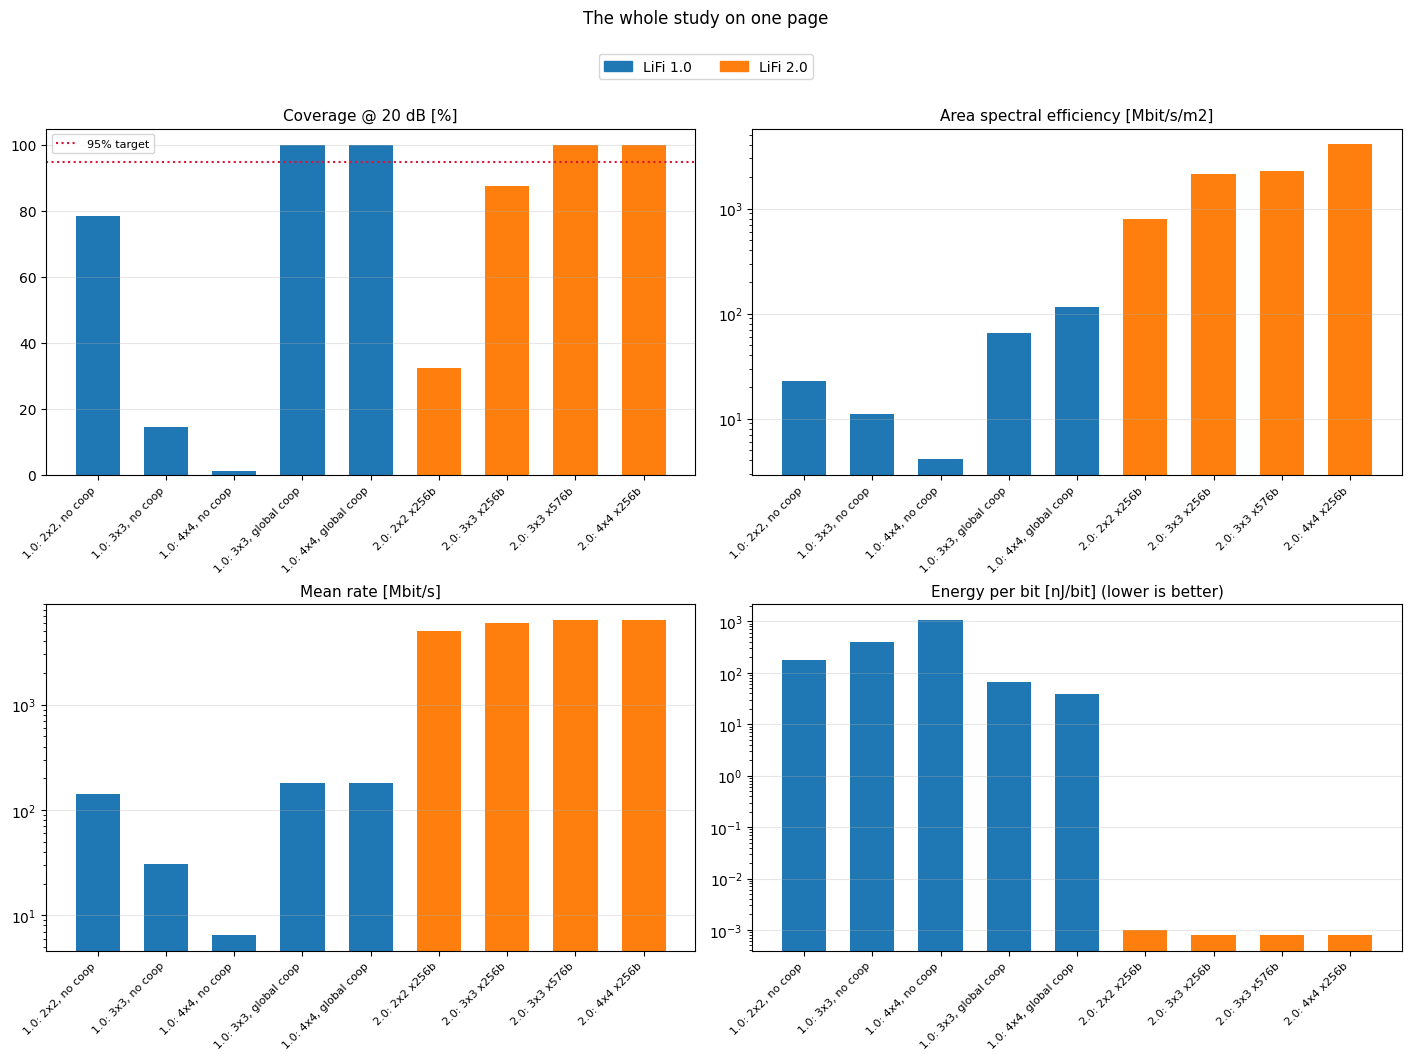

,Deployment,APs,P total [W],Coverage [%],Mean rate [Mbit/s],Cell-edge rate [Mbit/s],ASE [Mbit/s/m2],Energy/bit [nJ]
0,"1.0: 2x2, no coop",4,103.884,78.5,143.2,6.0,22.9,181.3559
1,"1.0: 3x3, no coop",9,108.895,14.7,30.9,3.1,11.1,391.2410
2,"1.0: 4x4, no coop",16,110.574,1.3,6.5,2.4,4.1,1068.2005
3,"1.0: 3x3, global coop",9,108.895,100.0,180.0,161.5,64.8,67.2011
4,"1.0: 4x4, global coop",16,110.574,100.0,180.0,163.0,115.2,38.3968
5,2.0: 2x2 x256b,4,0.020,32.6,4997.7,3527.8,799.6,0.0010
6,2.0: 3x3 x256b,9,0.045,87.6,5988.1,5231.8,2155.7,0.0008
7,2.0: 3x3 x576b,9,0.045,100.0,6341.7,5917.2,2283.0,0.0008
8,2.0: 4x4 x256b,16,0.080,100.0,6378.5,5920.0,4082.2,0.0008


In [10]:
summary = []
for lbl, n, cp in [("1.0: 2x2, no coop", 2, "none"), ("1.0: 3x3, no coop", 3, "none"),
                   ("1.0: 4x4, no coop", 4, "none"), ("1.0: 3x3, global coop", 3, "global"),
                   ("1.0: 4x4, global coop", 4, "global")]:
    s, P, nc, _ = evaluate_led(n, coop=cp)
    r, _ = metrics(s, B_LED, P, nc, lbl, tech="LiFi 1.0"); summary.append(r)
for lbl, n, m in [("2.0: 2x2 x256b", 2, 16), ("2.0: 3x3 x256b", 3, 16),
                  ("2.0: 3x3 x576b", 3, 24), ("2.0: 4x4 x256b", 4, 16)]:
    s, P, nc = evaluate_vcsel(n, m)
    r, _ = metrics(s, B_VCSEL, P, nc, lbl, tech="LiFi 2.0", **{"Total beams": nc*m*m})
    summary.append(r)
sdf = pd.DataFrame(summary)

# grouped bar charts, one per metric -- the standard way papers in this field lay out a
# multi-configuration, multi-metric comparison (vs. the single bubble-chart alternative,
# which packs 4 dimensions into one axis and gets hard to read fast)
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5), constrained_layout=True)
colors = sdf["tech"].map({"LiFi 1.0": "tab:blue", "LiFi 2.0": "tab:orange"})
x = np.arange(len(sdf))

panels = [
    ("Coverage [%]", "Coverage @ 20 dB [%]", False),
    ("ASE [Mbit/s/m2]", "Area spectral efficiency [Mbit/s/m2]", True),
    ("Mean rate [Mbit/s]", "Mean rate [Mbit/s]", True),
    ("Energy/bit [nJ]", "Energy per bit [nJ/bit] (lower is better)", True),
]
for ax, (col, title, log_scale) in zip(axes.ravel(), panels):
    ax.bar(x, sdf[col], color=colors, width=0.65)
    if log_scale:
        ax.set_yscale("log")
    ax.set_xticks(x); ax.set_xticklabels(sdf["Deployment"], rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11)
    ax.grid(alpha=.3, axis="y")
axes[0, 0].axhline(COV_TARGET, color="crimson", ls=":", lw=1.5, label="95% target")
axes[0, 0].legend(fontsize=8)

from matplotlib.patches import Patch
fig.legend(handles=[Patch(color="tab:blue", label="LiFi 1.0"), Patch(color="tab:orange", label="LiFi 2.0")],
           loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.06), fontsize=10)
fig.suptitle("The whole study on one page", y=1.1)
plt.show()

sdf[["Deployment", "APs", "P total [W]", "Coverage [%]", "Mean rate [Mbit/s]",
     "Cell-edge rate [Mbit/s]", "ASE [Mbit/s/m2]", "Energy/bit [nJ]"]]

### 8.2 Discussion

Per watt, the two technologies are four orders of magnitude apart, but that number needs to be read carefully: the LED's watts are not spent on communication. They light the room, which the VCSEL does not do at all. The fair reading is therefore not "LiFi 1.0 is a thousand times less efficient", but that communication is essentially free for LiFi 1.0, since it rides on top of the lighting budget, while for LiFi 2.0 it is the only cost there is.

Directivity explains almost everything else: it is what makes the LED a good lamp and a poor multi-cell transmitter, since its wide lobe sprays energy into every neighbouring cell, and it is what makes the VCSEL a poor lamp and an excellent multi-cell transmitter, since its cells stay orthogonal by geometry alone, with no coordination needed. The receiver FoV interacts with this in the same way for both: it filters interference exactly as it filters signal, the same mechanism `[VCSEL-Precoding]` reports in its Sec. VI, where a wider FoV captures more interference and lowers the SINR.

Putting the cases together, LiFi 2.0 has three real advantages over LiFi 1.0, and the single-cell notebook could only see the first of them: its bandwidth (2 GHz vs 20 MHz) opens a 44x rate gap that no LED deployment can close; its directivity gives interference-free densification( the ability to scale at all); and its power is decoupled from any lighting requirement. The last two are architectural and only become visible at the network level, which is exactly why this multi-cell analysis was needed.

That scaling ability still has a cost: LiFi 2.0 needs thousands of beams, because an eye-safe 5 mW beam only clears 20 dB within about 6 cm of its axis. This is not a modelling artefact as it follows directly from directivity combined with eye safety, and it is precisely why the literature builds LiFi 2.0 as a grid of steerable beams (`[VCSEL-Precoding]` and its ref. [30]) rather than as a handful of transmitters. Directivity, is basically paid for in emitters instead of watts.

## 9. Conclusions

| Feature | LiFi 1.0 (LED) | LiFi 2.0 (VCSEL) |
|---|---|---|
| Optical source | LED | VCSEL array with beam selection |
| Emission pattern | Lambertian | Gaussian beam |
| Available power | High (tens of W, set by lighting) | Limited by eye safety (mW per emitter) |
| Directivity | Low | High |
| Single-AP coverage | High (78.5% at 2x2, its lighting-driven deployment) | Low (needs thousands of beams for 100%) |
| Interference | High (wide lobes overlap between cells) | Low (beams stay within their own cell) |
| Throughput | Moderate (capped by 20 MHz bandwidth) | Very high (multi-Gbit/s, 2 GHz bandwidth) |
| What it scales with | Illumination requirements + coordination | Densification + beam steering |
| Main limitation | Co-channel interference | Deployment complexity (thousands of beams) |

LiFi 1.0 is the right answer when the room needs to be lit anyway and the rate requirement is modest: the communication link is essentially free, and a 2x2 deployment, the same one its lighting already requires, gives 78.5% coverage with no coordination, or close to 100% with it. It can never exceed roughly 150 Mbit/s of mean throughput, however, no matter what is deployed. LiFi 2.0, in contrast, is clearly superior whenever high throughput, high density, or high coverage is needed: 100% coverage with 3x3-4x4 APs, multi-gigabit mean rates, tens of milliwatts instead of roughly 104 W, and, most importantly, it actually scales.

LiFi 2.0 wins clearly whenever the network has to be dense. In a single cell the comparison was nuanced, since a lone VCSEL cannot even cover a room by itself. In a network the answer becomes unambiguous, and the reason is not speed but directivity.

Cooperation is what makes LiFi 1.0 viable as a dense network, by converting its worst enemy, interference, into useful signal. For LiFi 2.0 it is nearly irrelevant, because directivity already delivers the same effect for free. In short, LiFi 1.0 needs a coordinated, synchronized network, while LiFi 2.0 needs good optics.

For 6G, this points to two different roles rather than a single winner. LiFi 1.0 fits as a low-cost overlay on the existing lighting infrastructure, with free power, decent coverage and modest rates, provided its APs are coordinated. LiFi 2.0 is the technology that actually scales into an ultra-dense, multi-gigabit indoor network, at negligible power cost and without tight inter-AP coordination, but it needs a grid of thousands of steerable beams, which is a real hardware cost of its own. The two are complementary rather than competing: the same fact that makes LiFi 1.0 look weak, its power being dictated by lighting, is what makes it free, and the same fact that makes LiFi 2.0 look expensive, its arrays of emitters, is what makes it scale.

## 10. Limitations

**1. Beam waist is the parameter the conclusions depend on most.** This notebook uses the realistic $w_0 = 5\ \mu m$ from `[Eye-Safety]`, rather than the sub-wavelength 0.45 um listed in `[VCSEL-Precoding]` Table I. That choice sets both the beam width (12 cm vs 1.34 m) and the eye-safe power (a few mW vs an inflated 225 mW), and the two have to stay consistent with each other. The check below re-runs the headline configuration with the paper's own value, to see how much the conclusions actually depend on this choice.

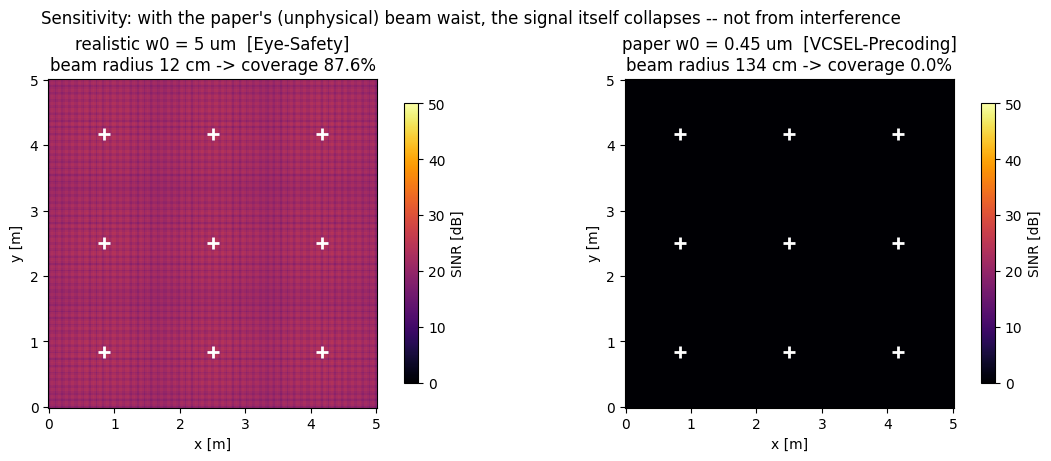

With w0 = 0.45 um the same 5 mW spreads over a beam ~125x wider in area (134 cm
radius instead of 12 cm), so the peak signal alone collapses by about 42 dB.
Interference stays three orders of magnitude below the noise floor throughout --
it is not the cause. The comparison therefore rests on using a physically valid
beam (Sec. 2.2), not on avoiding interference between wide beams.


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.5), constrained_layout=True)
cm = plt.cm.inferno.copy(); cm.set_bad("black")
for a, (w0, tag) in zip(ax, [(W0, "realistic w0 = 5 um  [Eye-Safety]"),
                             (W0_PAPER, "paper w0 = 0.45 um  [VCSEL-Precoding]")]):
    s, P, nc = evaluate_vcsel(3, 16, w0=w0)
    zr = np.pi*w0**2/LAMBDA; br = w0*np.sqrt(1 + (dz/zr)**2)*100
    dB = np.where(s > 0, 10*np.log10(np.where(s > 0, s, 1)), np.nan)
    im = a.pcolormesh(X, Y, dB, shading="auto", cmap=cm, vmin=0, vmax=50)
    a.plot(ap_lattice(3)[:, 0], ap_lattice(3)[:, 1], "w+", ms=9, mew=2)
    a.set_title(f"{tag}\nbeam radius {br:.0f} cm -> coverage {100*np.mean(s >= GAMMA_TH):.1f}%")
    a.set_xlabel("x [m]"); a.set_ylabel("y [m]"); a.set_aspect("equal")
    fig.colorbar(im, ax=a, label="SINR [dB]", shrink=0.85)
fig.suptitle("Sensitivity: with the paper's (unphysical) beam waist, "
             "the signal itself collapses -- not from interference")
plt.show()
print("With w0 = 0.45 um the same 5 mW spreads over a beam ~125x wider in area (134 cm")
print("radius instead of 12 cm), so the peak signal alone collapses by about 42 dB.")
print("Interference stays three orders of magnitude below the noise floor throughout --")
print("it is not the cause. The comparison therefore rests on using a physically valid")
print("beam (Sec. 2.2), not on avoiding interference between wide beams.")

**2. Simplified beamforming.** APs use beam selection rather than full precoding, so LiFi 2.0's results here should be read as a lower bound on what a properly precoded array could achieve.

**3. Interference under beam selection is modelled as an expected value** (an average over the interferer's beams, assuming users uniformly distributed per cell), which is neither a best case nor a worst case. This is the most debatable assumption in the notebook; a heavily loaded network with clustered users would sit somewhere between the two.

**4. The eye-safety budget for the array follows a specific reading of `[Eye-Safety]`.** Treating each AP as an independent budget is this notebook's own interpretation of its subtense-based classification, not a rule the paper states explicitly. The within-AP treatment is deliberately conservative, since the $C_6$ relaxation for extended sources would in principle allow more array power than assumed here.

**5. Cooperation is idealized**, assuming perfect synchronization, perfect channel state information, and no backhaul cost, so its benefit should be read as an upper bound rather than something immediately achievable.

**6. Only one active user is modelled per AP**; multi-user scheduling within a single cell is not simulated.

**7. Both channel models are LOS only**, matching both reference papers. Adding NLOS paths would help LiFi 1.0's coverage somewhat, but it would also add to its interference.

**8. Users are static, pointing straight up, with no blockage modelled.** Random device orientation would penalize LiFi 2.0 more than LiFi 1.0, since a narrow beam is far more sensitive to misalignment than a wide Lambertian lobe. This is arguably LiFi 2.0's real weak point, and the most valuable direction for future work.

**9. Users are distributed uniformly across the room.** A more realistic distribution, concentrated around desks and seating, would favour LiFi 2.0 even further, since its whole advantage lies in aiming capacity at where users actually are.

## 11. References

| Key | Paper |
|---|---|
| `[RIS-VLC]` | B. Genoves Guzman, M. Morales Cespedes, V. P. Gil Jimenez, A. Garcia Armada, M. Brandt-Pearce, *Resource Allocation Exploiting Reflective Surfaces to Minimize the Outage Probability in VLC*, IEEE Trans. Wireless Commun., vol. 24, no. 7, pp. 5493-5507, July 2025 |
| `[VCSEL-Precoding]` | H. Safi et al., *Energy-Efficient Precoding for Dense VCSEL-Based OWC Systems Under a Cooperative Broadcast Model*, IEEE GLOBECOM 2025, pp. 1113-1116 |
| `[Capacity-Bound]` | J.-B. Wang et al., *Tight Bounds on Channel Capacity for Dimmable Visible Light Communications*, J. Lightw. Technol., vol. 31, no. 23, pp. 3771-3779, Dec. 2013 |
| `[Eye-Safety]` | M. Dehghani Soltani et al., *Safety Analysis for Laser-Based Optical Wireless Communications: A Tutorial*, Proc. IEEE, vol. 110, no. 8, pp. 1045-1072, Aug. 2022 |
| `[VCSEL-70Gbps]` | H. Kazemi et al., *Achieving 70 Gb/s Over a VCSEL-Based Optical Wireless Link Using a Multimode Fibre Photoreceiver*, 2025 |

**Cited inside the reference papers, used as supporting context**:

- H. Kazemi et al., *A Novel Terabit Grid-of-Beam Optical Wireless Multi-User Access Network With Beam Clustering* -- ref. [30] of `[VCSEL-Precoding]`: the grid-of-beam architecture that the "thousands of beams" result in Section 3 points to.
- M. D. Soltani et al., *Terabit Indoor Laser-based Wireless Communications: LiFi 2.0 for 6G* -- ref. [3] of `[VCSEL-Precoding]`: the LiFi 2.0 / 6G vision referenced in the introduction.
- C. Chen, D. Tsonev, H. Haas, *Joint Transmission in Indoor VLC Downlink Cellular Networks* -- ref. [18] of `[VCSEL-Precoding]`: the joint-transmission technique modelled in Section 7.